In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
data,tar=mnist['data'],mnist['target']
tar=np.array(tar).astype(int)

In [3]:
y=mnist['target']
y=np.array(y).astype(int)
Y_raw,y_raw=y[:60000].copy(),y[60000:].copy()
print(y_raw[1])

2


In [4]:
print(len(data))
L=[]
mis=[]

70000


In [5]:
def create_one_hot(labels, num_classes=10):

  one_hot_matrix = np.zeros((labels.size, num_classes))
  print(labels.size)
  one_hot_matrix[np.arange(labels.size), labels] = 1
  return one_hot_matrix

def show(im, p=" ",  n=20):
    cols = 5
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, rows*2.5))
    axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(im[i].reshape(28,28), cmap='gray')
        axes[i].set_title(f'Pred:{p[i]}  ', fontsize=9, color='red')
        axes[i].axis('off')

    plt.suptitle(f'Showing {n} of {len(im)} total mistakes', fontsize=12)
    plt.tight_layout()
    plt.savefig('mistakes.png', dpi=150, bbox_inches='tight')
    plt.show()


def relu(var):
  return var*(var>0)

def relu_d(var):
    return 1.0 * (var > 0)


def softmax(var):
  evar=np.exp(var-np.max(var,axis=1,keepdims=True))
  return evar/np.sum(evar,axis=1,keepdims=True)


def for_prop(w1,w2,w3,b1,b2,b3):
  global X_train
  z1=X_train@w1+b1
  a1=relu(z1)
  z2=a1@w2+b2
  a2=relu(z2)
  z3=a2@w3+b3
  a3=softmax(z3)
  return a1,z1,a2,z2,a3,z3

def loss(ypri):
  global Y_train
  return -np.sum(Y_train*np.log(ypri+1e-8))/ypri.shape[0]



def back_prop(a1,z1,a2,z2,a3,z3,w1,w2,w3,x=False,y=False):
  global X_train,Y_train
  if(x):
    pass
  else:
    x=X_train
    y=Y_train
  m=X_train.shape[0]
  dz3=a3-Y_train
  dw3=a2.T@dz3/m
  dd3=np.sum(dz3,axis=0,keepdims=True)/m
  da2=dz3@w3.T
  dz2=da2*relu_d(z2)
  dw2=a1.T@dz2/m
  dd2=np.sum(dz2,axis=0,keepdims=True)/m
  da1=dz2@w2.T
  dz1=da1*relu_d(z1)
  dw1=X_train.T@dz1/m
  dd1=np.sum(dz1,axis=0,keepdims=True)/m
  return dw1,dd1,dw2,dd2,dw3,dd3


def fit(w1,w2,w3,b1,b2,b3,epioc,lr):
  global L

  for _ in range(epioc):
    a1,z1,a2,z2,a3,z3=for_prop(w1,w2,w3,b1,b2,b3)
    L.append(loss(a3))
    dw1,dd1,dw2,dd2,dw3,dd3=back_prop(a1,z1,a2,z2,a3,z3,w1,w2,w3)
    w1=w1-dw1*lr
    w2-=dw2*lr
    w3-=dw3*lr
    b1-=dd1*lr
    b2-=dd2*lr
    b3-=dd3*lr
  print(np.shape(dw1),np.shape(dw3))
  return w1,w2,w3,b1,b2,b3



def test(x,y_r):
  global w1,w2,w3,b1,b2,b3
  z1=x@w1+b1
  a1=relu(z1)
  z2=a1@w2+b2
  a2=relu(z2)
  z3=a2@w3+b3
  a3=softmax(z3)
  acc=np.argmax(a3,axis=1)
  return np.mean(acc==y_r)*100


def mistakes(a3,y):
  #pass a3 as the x so that it can directly do all
  global data
  x=np.argmax(a3,axis=1)
  wrong_pre=x!=y
  wrong_ind=np.where(wrong_pre)[0]
  wrong_img=data[wrong_ind]
  wrong_imgp=x[wrong_ind]
  print("wrong pred are ",len(wrong_img))
  return wrong_img,wrong_imgp,y[wrong_ind]



def get_preds(X):
    global w1,w2,w3,b1,b2,b3
    z1=X@w1+b1; a1=relu(z1)
    z2=a1@w2+b2; a2=relu(z2)
    z3=a2@w3+b3; a3=softmax(z3)
    return np.argmax(a3, axis=1), a3








In [6]:
data=data/255
tar=create_one_hot(tar)
X_train,x_test,Y_train,y_test=data[:60000].copy(),data[60000:].copy(),tar[:60000].copy(),tar[60000:].copy()
print(y_test[1])

70000
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
w1=(np.random.rand(X_train.shape[1],128)-0.5)*0.1
b1=(np.random.rand(1,128)-0.5)*0.1
w2=(np.random.rand(128,64)-0.5)*0.1
b2=(np.random.rand(1,64)-0.5)*0.1
w3=(np.random.rand(64,10)-0.5)*0.1
b3=(np.random.rand(1,10)-0.5)*0.1

In [8]:
a1,z1,a2,z2,a3,z3=for_prop(w1,w2,w3,b1,b2,b3)

In [9]:
print(a3)
print(loss(a3))

[[0.10089911 0.09444603 0.10059302 ... 0.10006707 0.10113012 0.10006425]
 [0.10117229 0.09495275 0.10102238 ... 0.0998603  0.10203033 0.10089347]
 [0.10037156 0.09521779 0.10064749 ... 0.10006945 0.10130507 0.10000593]
 ...
 [0.1008762  0.09456277 0.10076476 ... 0.09960139 0.10203842 0.10004444]
 [0.10170439 0.09486427 0.10207188 ... 0.10004386 0.10193076 0.09979629]
 [0.10056859 0.09457529 0.10139063 ... 0.100104   0.10212709 0.10017243]]
2.3038432417847234


In [10]:
import json

with open(r'C:\Users\arvar\OneDrive\Desktop\NN\weights.json', 'r') as file:
    saved_parameters = json.load(file)

# 2. Convert the lists back into NumPy arrays
# (Make sure the keys match exactly how you saved them)
w1 = np.array(saved_parameters['w1'])
b1 = np.array(saved_parameters['b1'])
w2 = np.array(saved_parameters['w2'])
b2 = np.array(saved_parameters['b2'])
w3 = np.array(saved_parameters['w3'])
b3 = np.array(saved_parameters['b3'])

In [19]:
a1,z1,a2,z2,a3,z3=for_prop(w1,w2,w3,b1,b2,b3)
print(loss(a3))

0.04004972277567299


In [20]:
print(test(x_test,y_raw))

97.61999999999999


wrong pred are  602


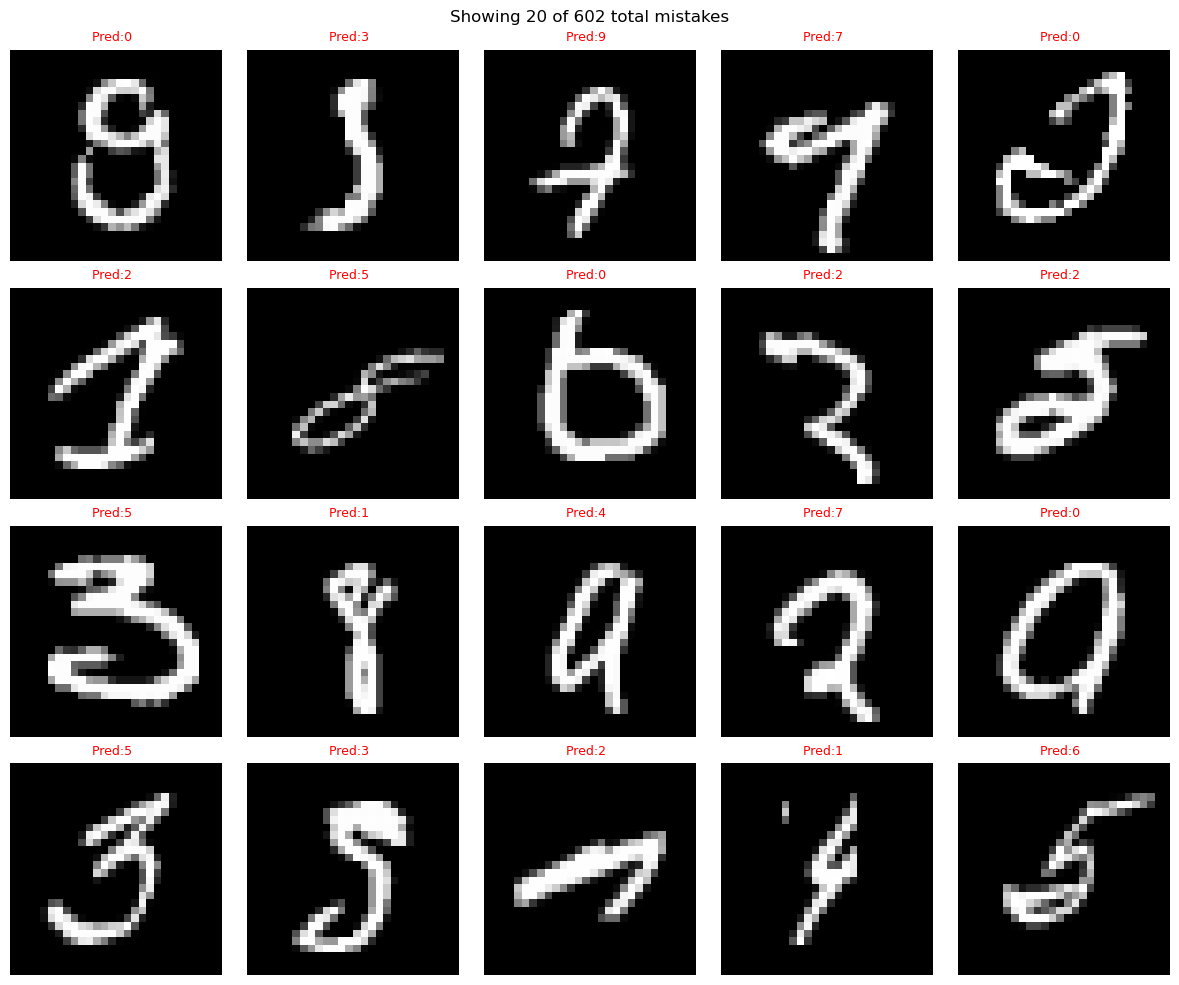

In [21]:
img,pimg,timg=mistakes(a3,Y_raw)
show(img,pimg)

In [14]:

# weights = {
#     'w1': w1.tolist(),
#     'w2': w2.tolist(),
#     'w3': w3.tolist(),
#     'b1': b1.tolist(),
#     'b2': b2.tolist(),
#     'b3': b3.tolist()
# }

# with open('weights1.json', 'w') as f:
#     json.dump(weights, f)

# from google.colab import files
# files.download('weights1.json')

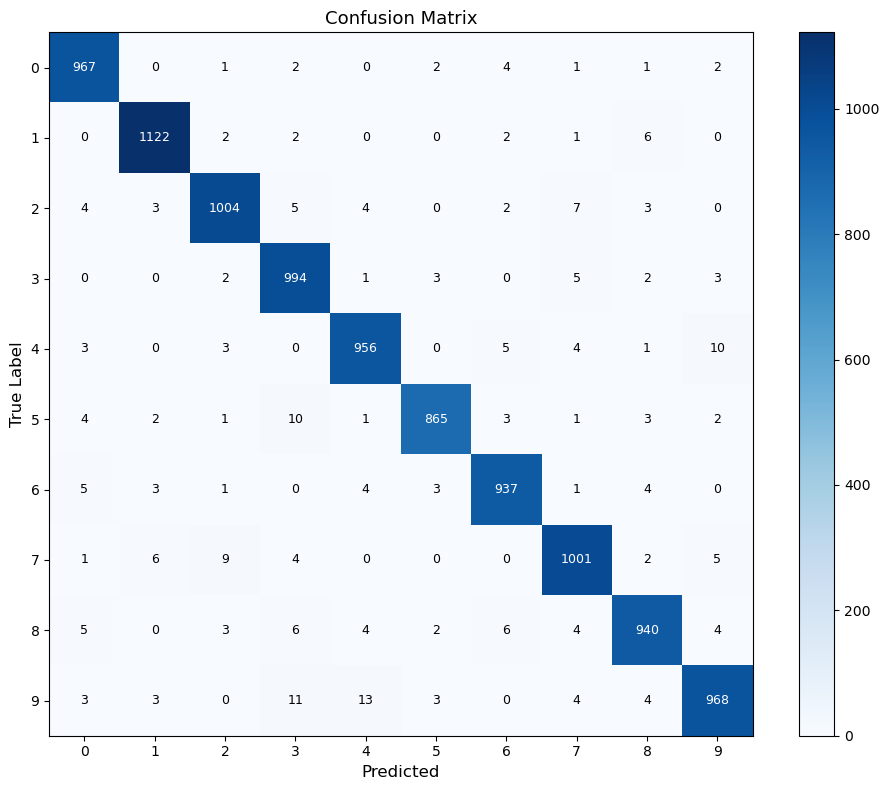

In [15]:
preds, probs = get_preds(x_test)
true = y_raw.astype(int)

cm = np.zeros((10,10), dtype=int)
for t, p in zip(true, preds):
    cm[t][p] += 1

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i][j] > cm.max()*0.5 else 'black'
        ax.text(j, i, cm[i][j], ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

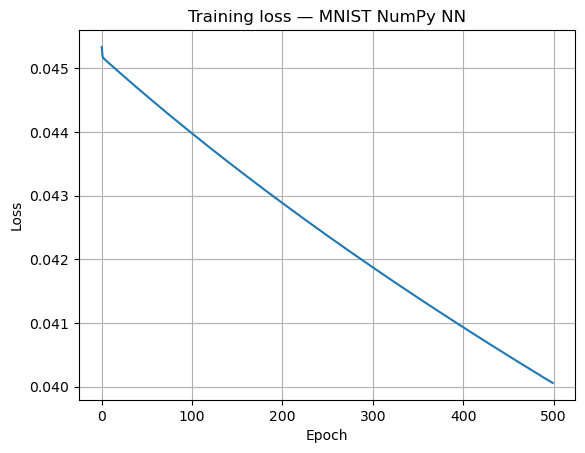

In [18]:
import matplotlib.pyplot as plt
plt.plot(L)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title('Training loss — MNIST NumPy NN')
plt.grid(True)
plt.show()

In [17]:
w1,w2,w3,b1,b2,b3=fit(w1,w2,w3,b1,b2,b3,500,0.1)

(784, 128) (64, 10)


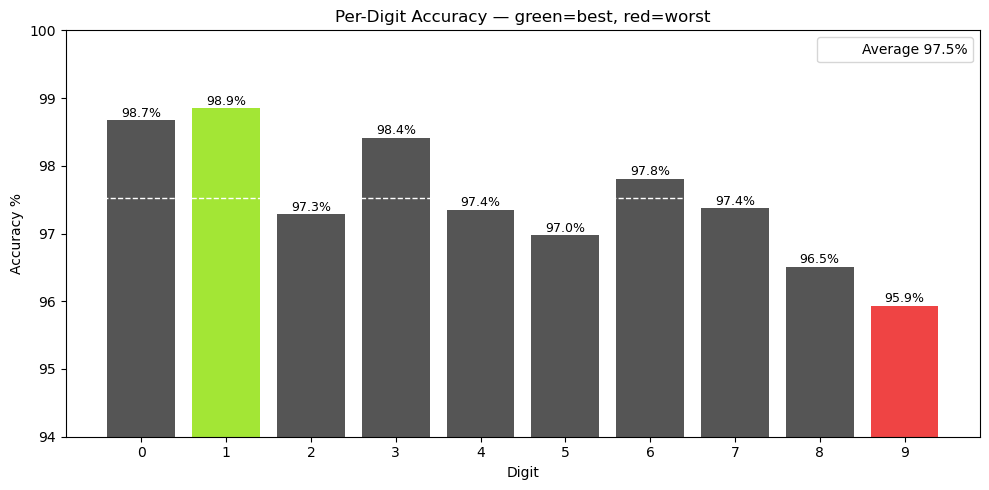

In [22]:
accs = []
for digit in range(10):
    mask = true == digit
    accs.append(np.mean(preds[mask] == true[mask]) * 100)

plt.figure(figsize=(10,5))
colors = ['#a3e635' if a==max(accs) else '#ef4444' if a==min(accs) else '#555' for a in accs]
plt.bar(range(10), accs, color=colors)
plt.axhline(y=np.mean(accs), color='white', linestyle='--', linewidth=1, label=f'Average {np.mean(accs):.1f}%')
for i, a in enumerate(accs):
    plt.text(i, a+0.05, f'{a:.1f}%', ha='center', fontsize=9)
plt.xlabel('Digit'); plt.ylabel('Accuracy %')
plt.title('Per-Digit Accuracy — green=best, red=worst')
plt.xticks(range(10)); plt.ylim([94, 100])
plt.legend()
plt.tight_layout()
plt.savefig('per_digit_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

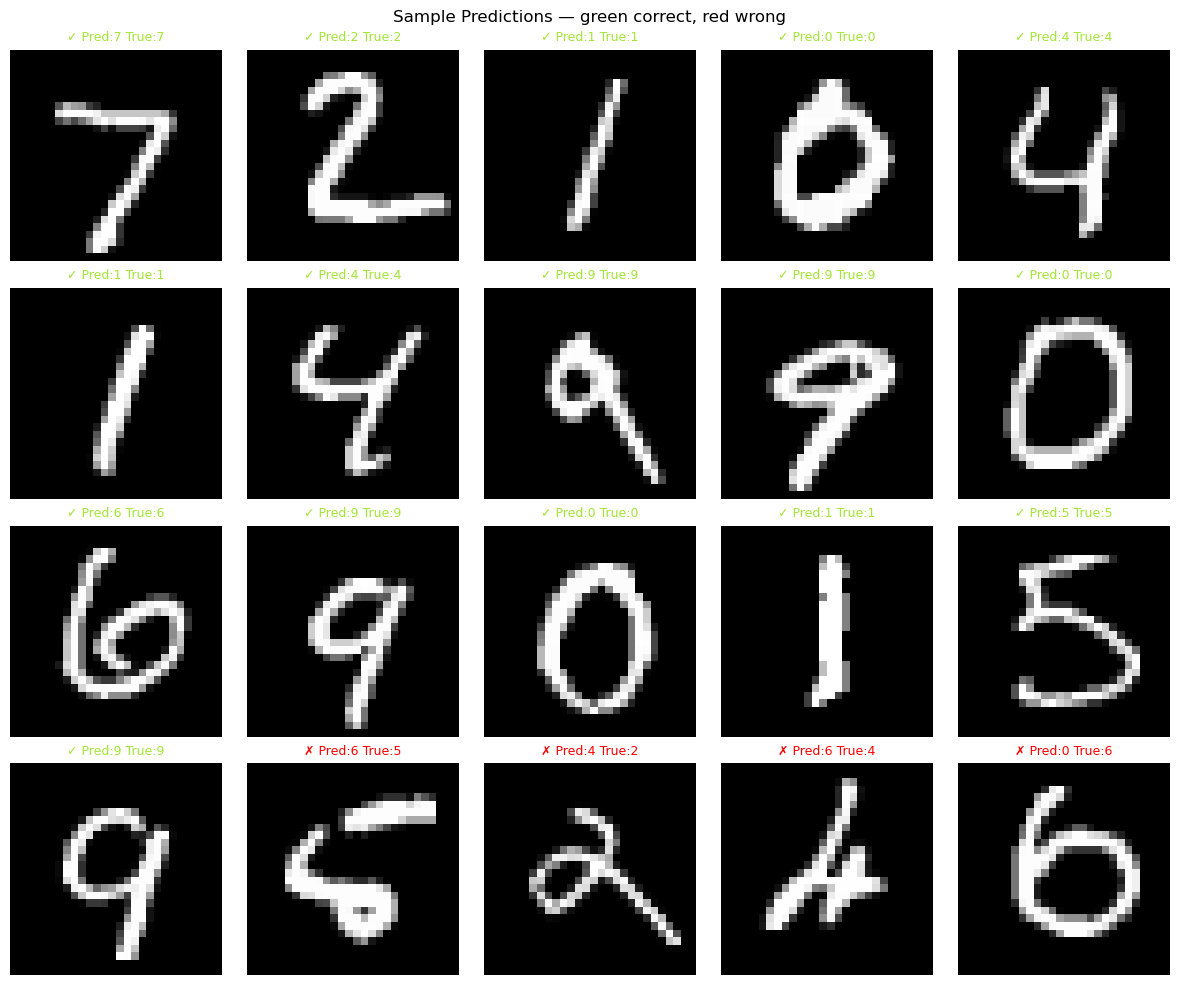

In [24]:
correct_idx = np.where(preds == true)[0][:16]
wrong_idx   = np.where(preds != true)[0][:4]
show_idx    = np.concatenate([correct_idx, wrong_idx])

fig, axes = plt.subplots(4, 5, figsize=(12,10))
axes = axes.flatten()

for i, idx in enumerate(show_idx):
    axes[i].imshow(x_test[idx].reshape(28,28), cmap='gray')
    color = '#a3e635' if preds[idx]==true[idx] else 'red'
    label = '✓' if preds[idx]==true[idx] else '✗'
    axes[i].set_title(f'{label} Pred:{preds[idx]} True:{true[idx]}', fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions — green correct, red wrong', fontsize=12)
plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()

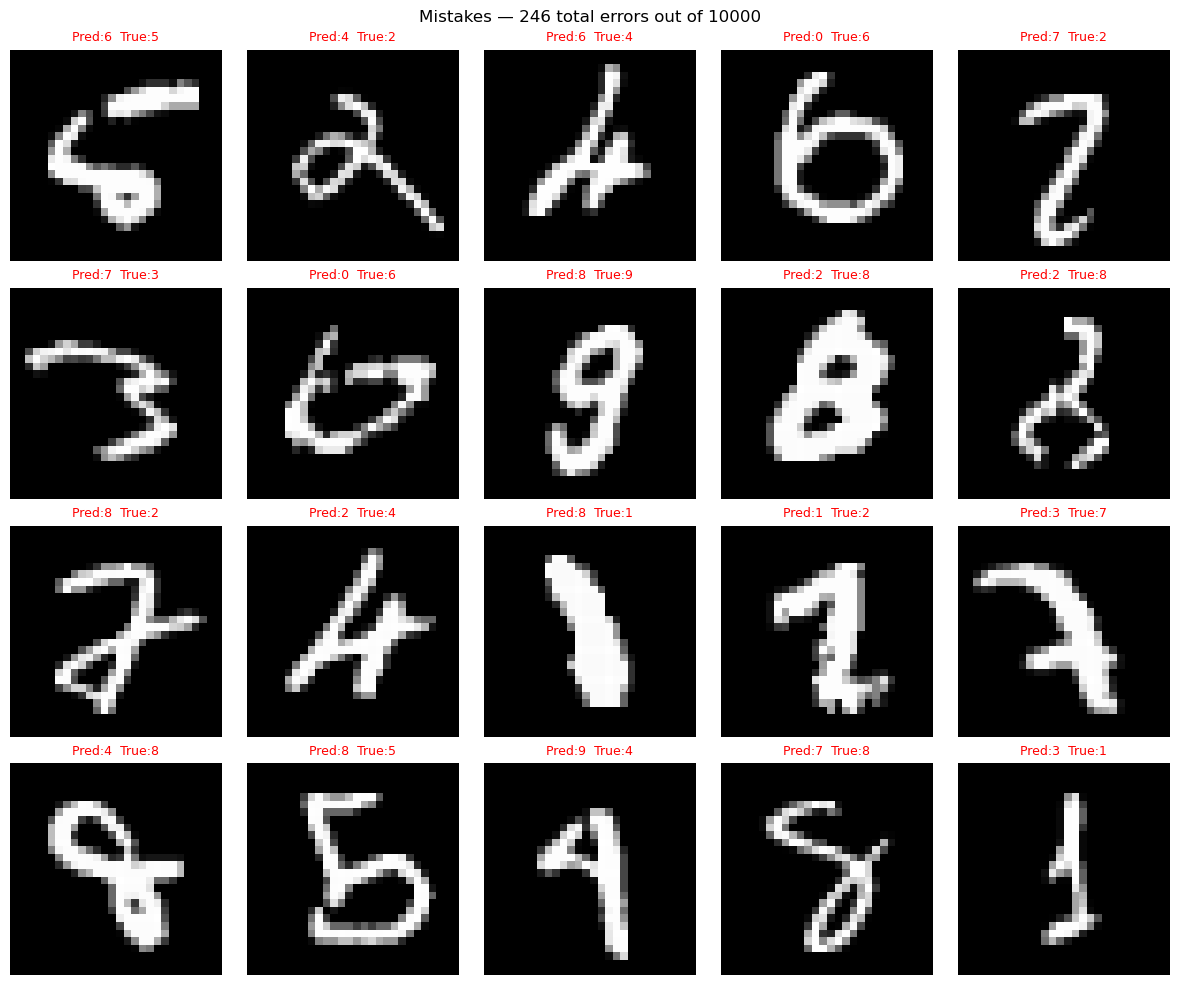

In [26]:
wrong_idx  = np.where(preds != true)[0]
wrong_img  = x_test[wrong_idx]
wrong_pred = preds[wrong_idx]
wrong_true = true[wrong_idx]

fig, axes = plt.subplots(4, 5, figsize=(12,10))
axes = axes.flatten()
for i in range(20):
    axes[i].imshow(wrong_img[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f'Pred:{wrong_pred[i]}  True:{wrong_true[i]}', fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle(f'Mistakes — {len(wrong_idx)} total errors out of {len(true)}', fontsize=12)
plt.tight_layout()
plt.savefig('mistakes_grid.png', dpi=150, bbox_inches='tight')
plt.show()

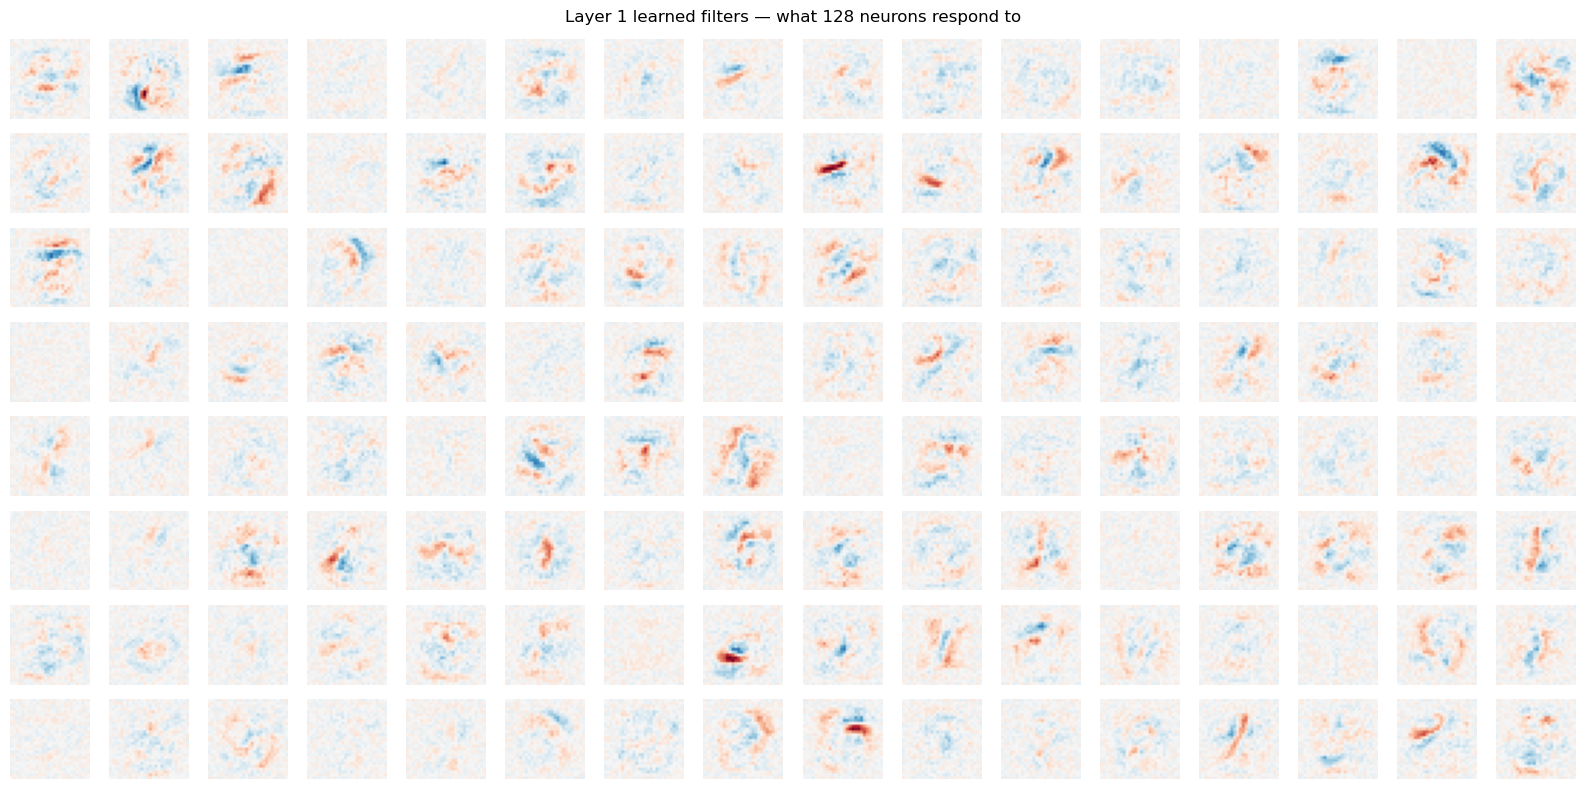

In [27]:
fig, axes = plt.subplots(8, 16, figsize=(16,8))
axes = axes.flatten()
for i in range(128):
    axes[i].imshow(w1[:, i].reshape(28,28), cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[i].axis('off')
plt.suptitle('Layer 1 learned filters — what 128 neurons respond to', fontsize=12)
plt.tight_layout()
plt.savefig('weight_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
from IPython.display import FileLink, display

# Generate clickable download links for each file
display(FileLink('confusion_matrix.png'))
display(FileLink('per_digit_accuracy.png'))
display(FileLink('predictions_grid.png'))
display(FileLink('mistakes_grid.png'))
display(FileLink('weight_visualization.png'))

C:\Users\arvar\confusion_matrix.png

C:\Users\arvar\per_digit_accuracy.png

C:\Users\arvar\predictions_grid.png

C:\Users\arvar\mistakes_grid.png

C:\Users\arvar\weight_visualization.png